# Stages 6 & 7: Model Development, Optimization & Selection
## Predictive Maintenance Diagnostic System (AI4I-PMDI Dataset)
**Course:** IT3051 - Fundamentals of Data Mining (SLIIT)  
**Group:** 05 - 'Cognita'  
**Dataset:** AI4I-PMDI Predictive Maintenance Dataset with Missingness & Imbalance  
**Target:** Multiclass Health State Classification (`Diagnostic` - 6 classes)  

---

### Notebook Navigation:
1. [Setup, Reproducibility & Processed Data Audit](#sec1)
2. [Validation Strategy & Performance Metric Rationale](#sec2)
3. [Stage 6: Baseline Model Development (5 Diverse Algorithms)](#sec3)
4. [Predictive Maintenance Operational Interpretation & Error Analysis](#sec4)
5. [Stage 7.1: Controlled Feature Engineering Ablation Experiment](#sec5)
6. [Stage 7.2: Class Imbalance Strategy Benchmark (Weighting vs SMOTE)](#sec6)
7. [Stage 7.3: Feature Selection & Permutation Importance](#sec7)
8. [Stage 7.4: Systematic Hyperparameter Optimization (RandomizedSearchCV)](#sec8)
9. [Final Model Selection Decision Framework](#sec9)
10. [Stage 7.5: Untouched Test Partition Evaluation (N=2,000)](#sec10)
11. [Production Pipeline Serialization & Single-Row Real-Time Inference](#sec11)
12. [Consolidated Master Experiment Log & Stage 8 Summary](#sec12)


<a id='sec1'></a>
## 1. Setup, Reproducibility & Processed Data Audit

In [1]:
import sys
import os
from pathlib import Path

# Add project root to sys.path so custom transformers in 'src' can be unpickled cleanly
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
import joblib

# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load processed partitions (fitted strictly on train, zero leakage into test)
X_train = pd.read_csv('../data/processed/X_train_processed.csv')
X_test = pd.read_csv('../data/processed/X_test_processed.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').iloc[:, 0]
y_test = pd.read_csv('../data/processed/y_test.csv').iloc[:, 0]

print(f"X_train Shape: {X_train.shape} | y_train Instances: {len(y_train)}")
print(f"X_test Shape:  {X_test.shape}  | y_test Instances:  {len(y_test)}")
print(f"Total Features (23): {list(X_train.columns)}")


X_train Shape: (8000, 23) | y_train Instances: 8000
X_test Shape:  (2000, 23)  | y_test Instances:  2000
Total Features (23): ['num__Air temperature (K)', 'num__Process temperature (K)', 'num__Rotational speed (rpm)', 'num__Torque (Nm)', 'num__Tool wear (min)', 'num__Temp_Difference', 'num__Mechanical_Power_W', 'num__Overstrain_Product', 'num__Missing_Sensors_Count', 'num__missingindicator_Air temperature (K)', 'num__missingindicator_Process temperature (K)', 'num__missingindicator_Rotational speed (rpm)', 'num__missingindicator_Torque (Nm)', 'num__missingindicator_Tool wear (min)', 'num__missingindicator_Temp_Difference', 'num__missingindicator_Mechanical_Power_W', 'num__missingindicator_Overstrain_Product', 'cat__Type_H', 'cat__Type_L', 'cat__Type_M', 'cat__Control_A', 'cat__Control_B', 'cat__Control_C']


In [2]:
# Inspect Target Distribution & Severe Class Imbalance
dist_df = pd.DataFrame({
    'Train Count': y_train.value_counts(),
    'Train %': (y_train.value_counts(normalize=True) * 100).round(2),
    'Test Count': y_test.value_counts(),
    'Test %': (y_test.value_counts(normalize=True) * 100).round(2),
})
print("Target Class Distribution across Partitions (Strict 80/20 Stratification):")
display(dist_df)


Target Class Distribution across Partitions (Strict 80/20 Stratification):


,Train Count,Train %,Test Count,Test %
Diagnostic,,,,
No failure,7722,96.52,1930,96.50
Heat Dissipation Failure,85,1.06,21,1.05
Overstrain Failure,78,0.98,20,1.00
Power Failure,66,0.82,17,0.85
Tool Wear Failure,34,0.43,8,0.40
Random Failures,15,0.19,4,0.20


<a id='sec2'></a>
## 2. Validation Strategy & Performance Metric Rationale

### Validation Strategy: Stratified 5-Fold Cross Validation
- **Partitioning:** The training set ($N=8,000$) is divided into 5 stratified folds (`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`).
- **Minority Preservation:** The rarest class, *Random Failures*, contains only $15$ instances in the training partition. A 5-fold stratification allocates exactly **3 instances per validation fold**. (A 10-fold split would allocate only 1 or 2 instances per fold, causing severe fold-level recall volatility).
- **Leak-Free Protocol:** The 2,000-instance test set remains **completely untouched and locked** until Stage 7 final evaluation. No hyperparameter tuning, model comparison, or feature selection touches the test partition.

### Evaluation Metrics Rationale
1. **Macro F1-Score (Primary Metric):** Unweighted arithmetic mean of F1-scores across all 6 diagnostic classes. Treats the ultra-rare *Random Failures* ($N=15$) and *Tool Wear Failure* ($N=34$) with the exact same importance as the majority *No failure* ($N=7,722$).
2. **Macro Recall & Balanced Accuracy:** Evaluates average sensitivity across classes. Essential in predictive maintenance where false negatives represent catastrophic tool breakage.
3. **Weighted F1-Score:** Weighted by class prevalence; provided to highlight how high accuracy ($>96.5\%$) masks poor minority detection in naive models.


<a id='sec3'></a>
## 3. Stage 6: Baseline Model Development (5 Diverse Algorithms)

We implement and benchmark FIVE mathematically diverse machine learning models:
1. **Multinomial Logistic Regression:** Regularized linear parametric baseline with L2 penalty (requires StandardScaler).
2. **Support Vector Classifier (RBF Kernel):** Maximum-margin kernel method operating in high-dimensional dual space (requires StandardScaler).
3. **Random Forest Classifier:** Bagging ensemble of deep de-correlated decision trees with balanced bootstrap subsampling (scale invariant).
4. **Extra Trees Classifier:** Extremely randomized trees with random split thresholds, reducing ensemble variance.
5. **HistGradientBoostingClassifier:** Fast histogram-binned sequential gradient boosting inspired by LightGBM.


In [3]:
# Display Pre-computed Baseline Leaderboard from Cross-Validation
baseline_df = pd.read_csv('../reports/model_comparison_baseline.csv')
print("=== Baseline Model Leaderboard (Stratified 5-Fold CV) ===")
display(baseline_df[['Model', 'Macro F1', 'Macro Recall', 'Balanced Accuracy', 'Weighted F1', 'Fit Time (s)']])


=== Baseline Model Leaderboard (Stratified 5-Fold CV) ===


,Model,Macro F1,Macro Recall,Balanced Accuracy,Weighted F1,Fit Time (s)
0,HistGradientBoosting,0.6830 ± 0.0313,0.6825 ± 0.0318,0.6825 ± 0.0318,0.9889 ± 0.0017,2.85s
1,Random Forest,0.6744 ± 0.0124,0.7828 ± 0.0241,0.7828 ± 0.0241,0.9786 ± 0.0022,0.40s
2,Extra Trees,0.5775 ± 0.0111,0.7560 ± 0.0435,0.7560 ± 0.0435,0.9596 ± 0.0024,0.32s
3,Support Vector Classifier,0.5489 ± 0.0132,0.8022 ± 0.0389,0.8022 ± 0.0389,0.8338 ± 0.0157,1.33s
4,Logistic Regression,0.5045 ± 0.0204,0.7975 ± 0.0262,0.7975 ± 0.0262,0.7353 ± 0.0277,0.48s


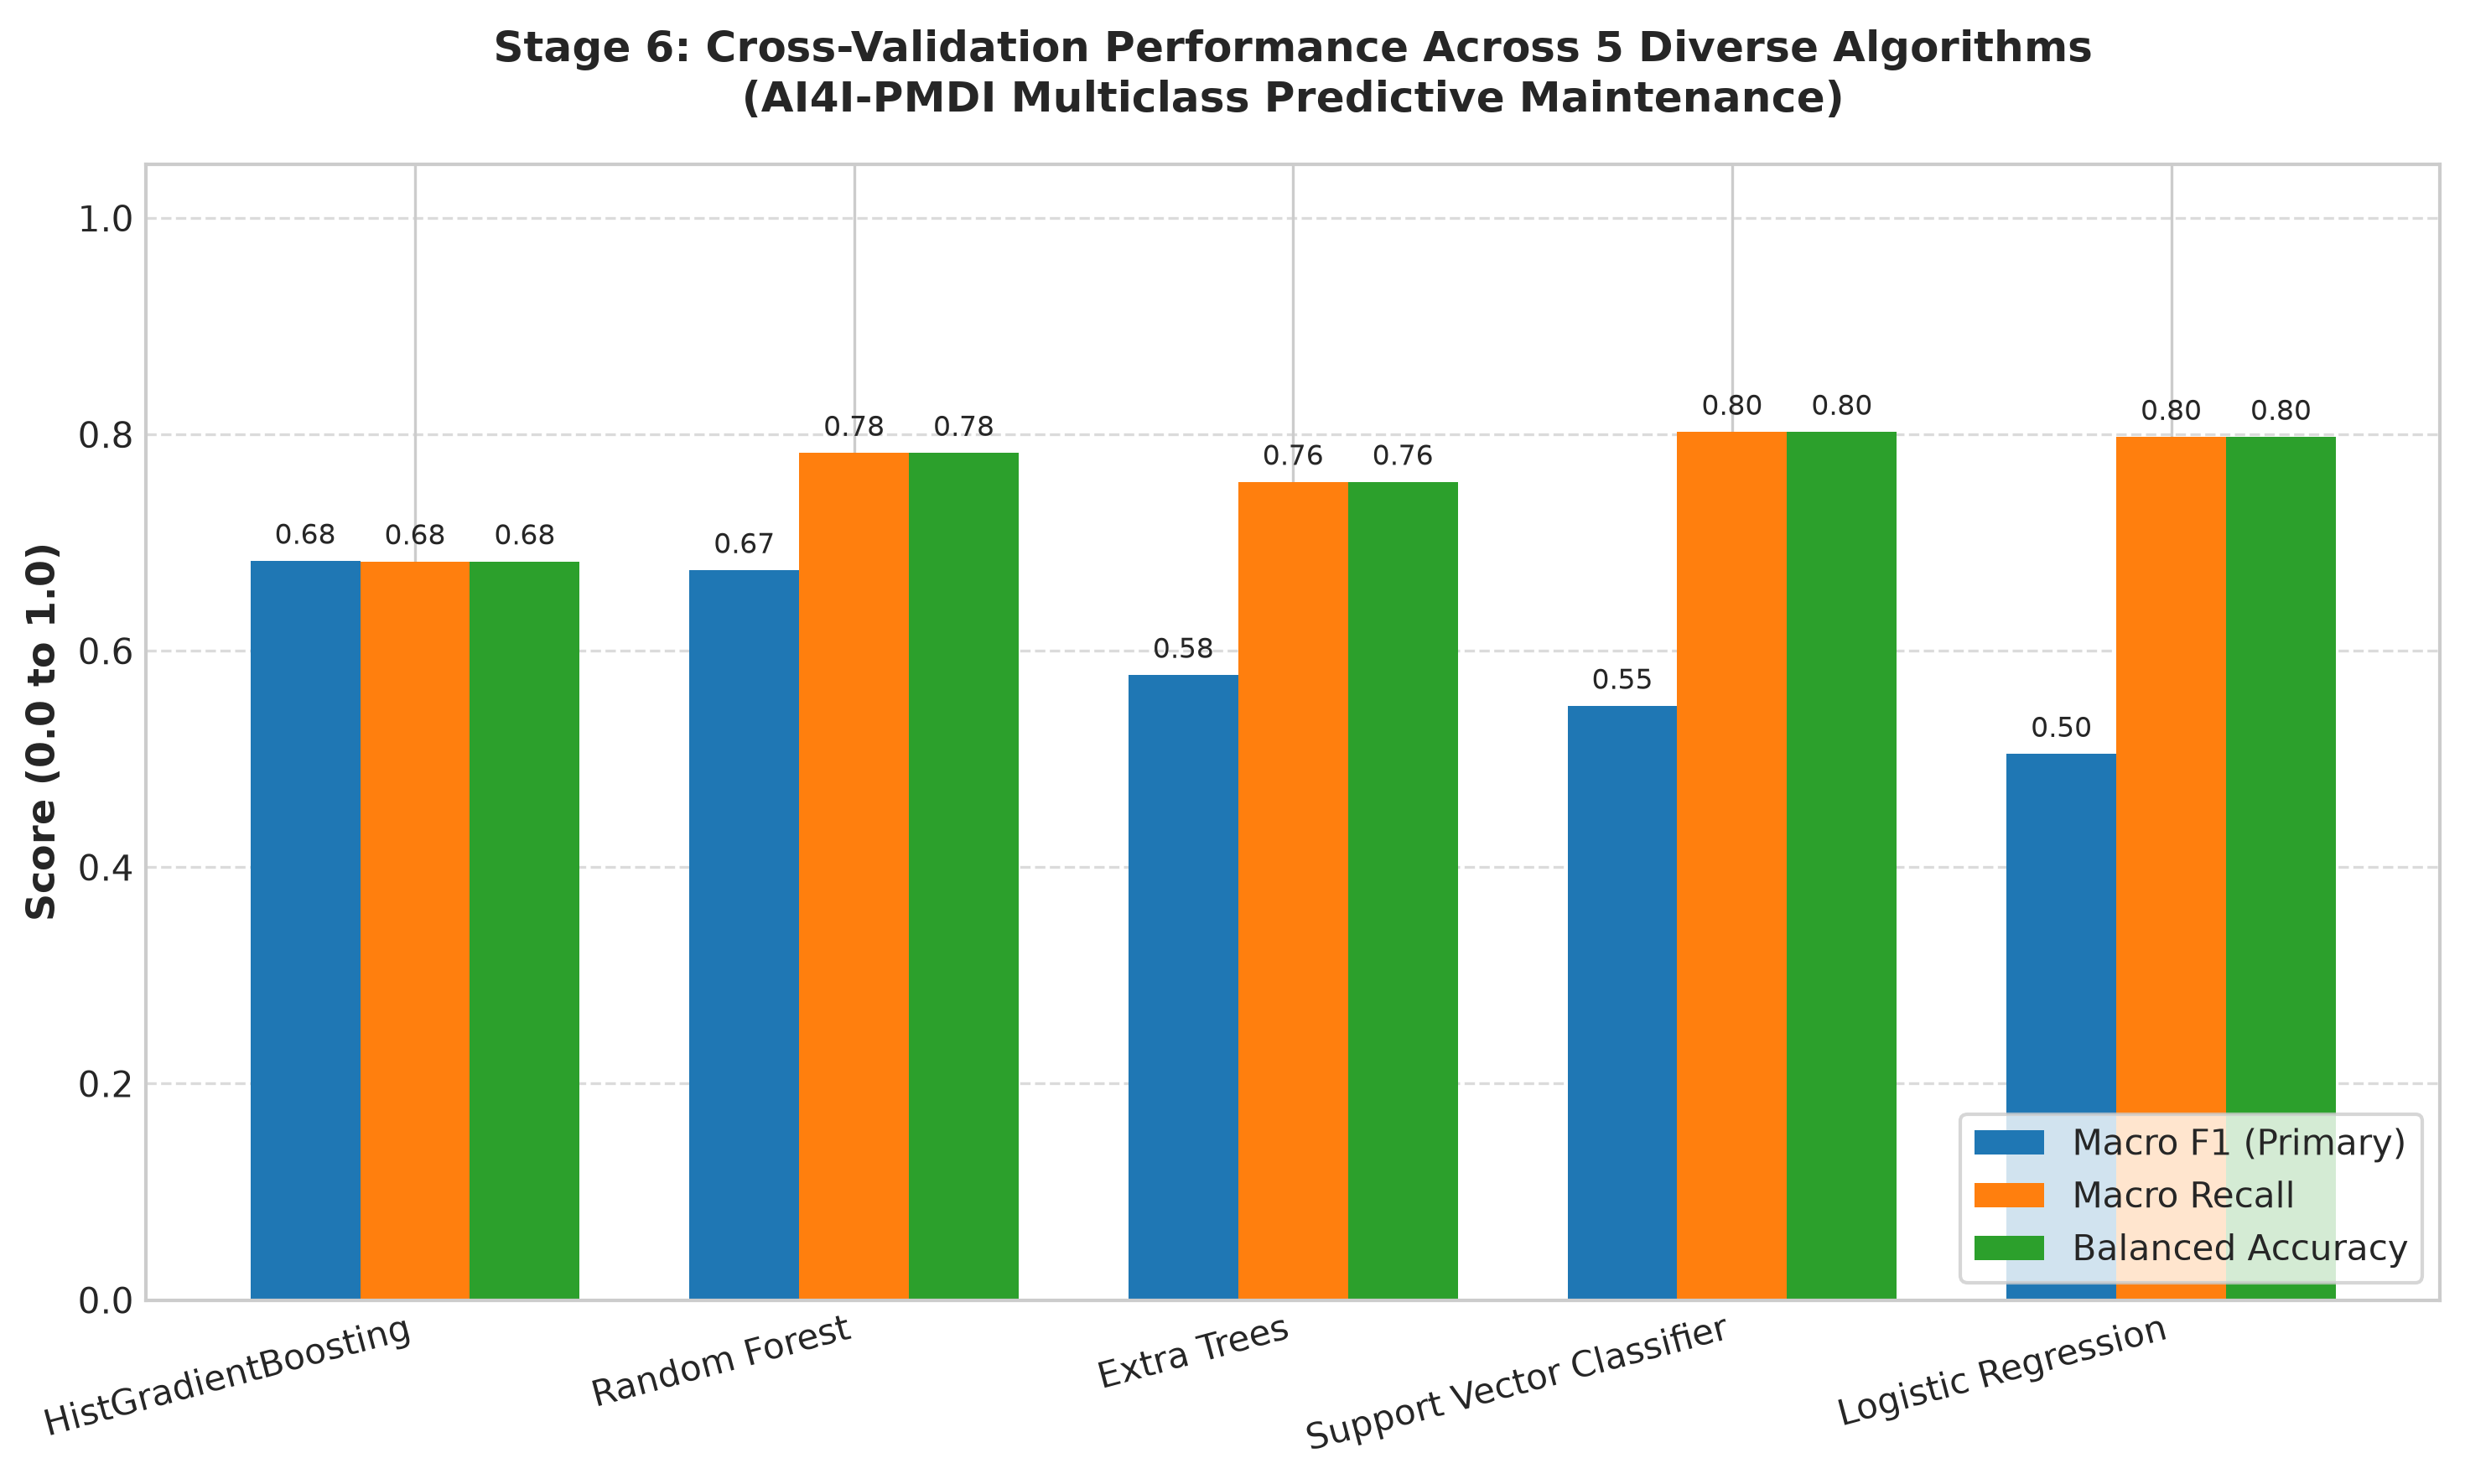

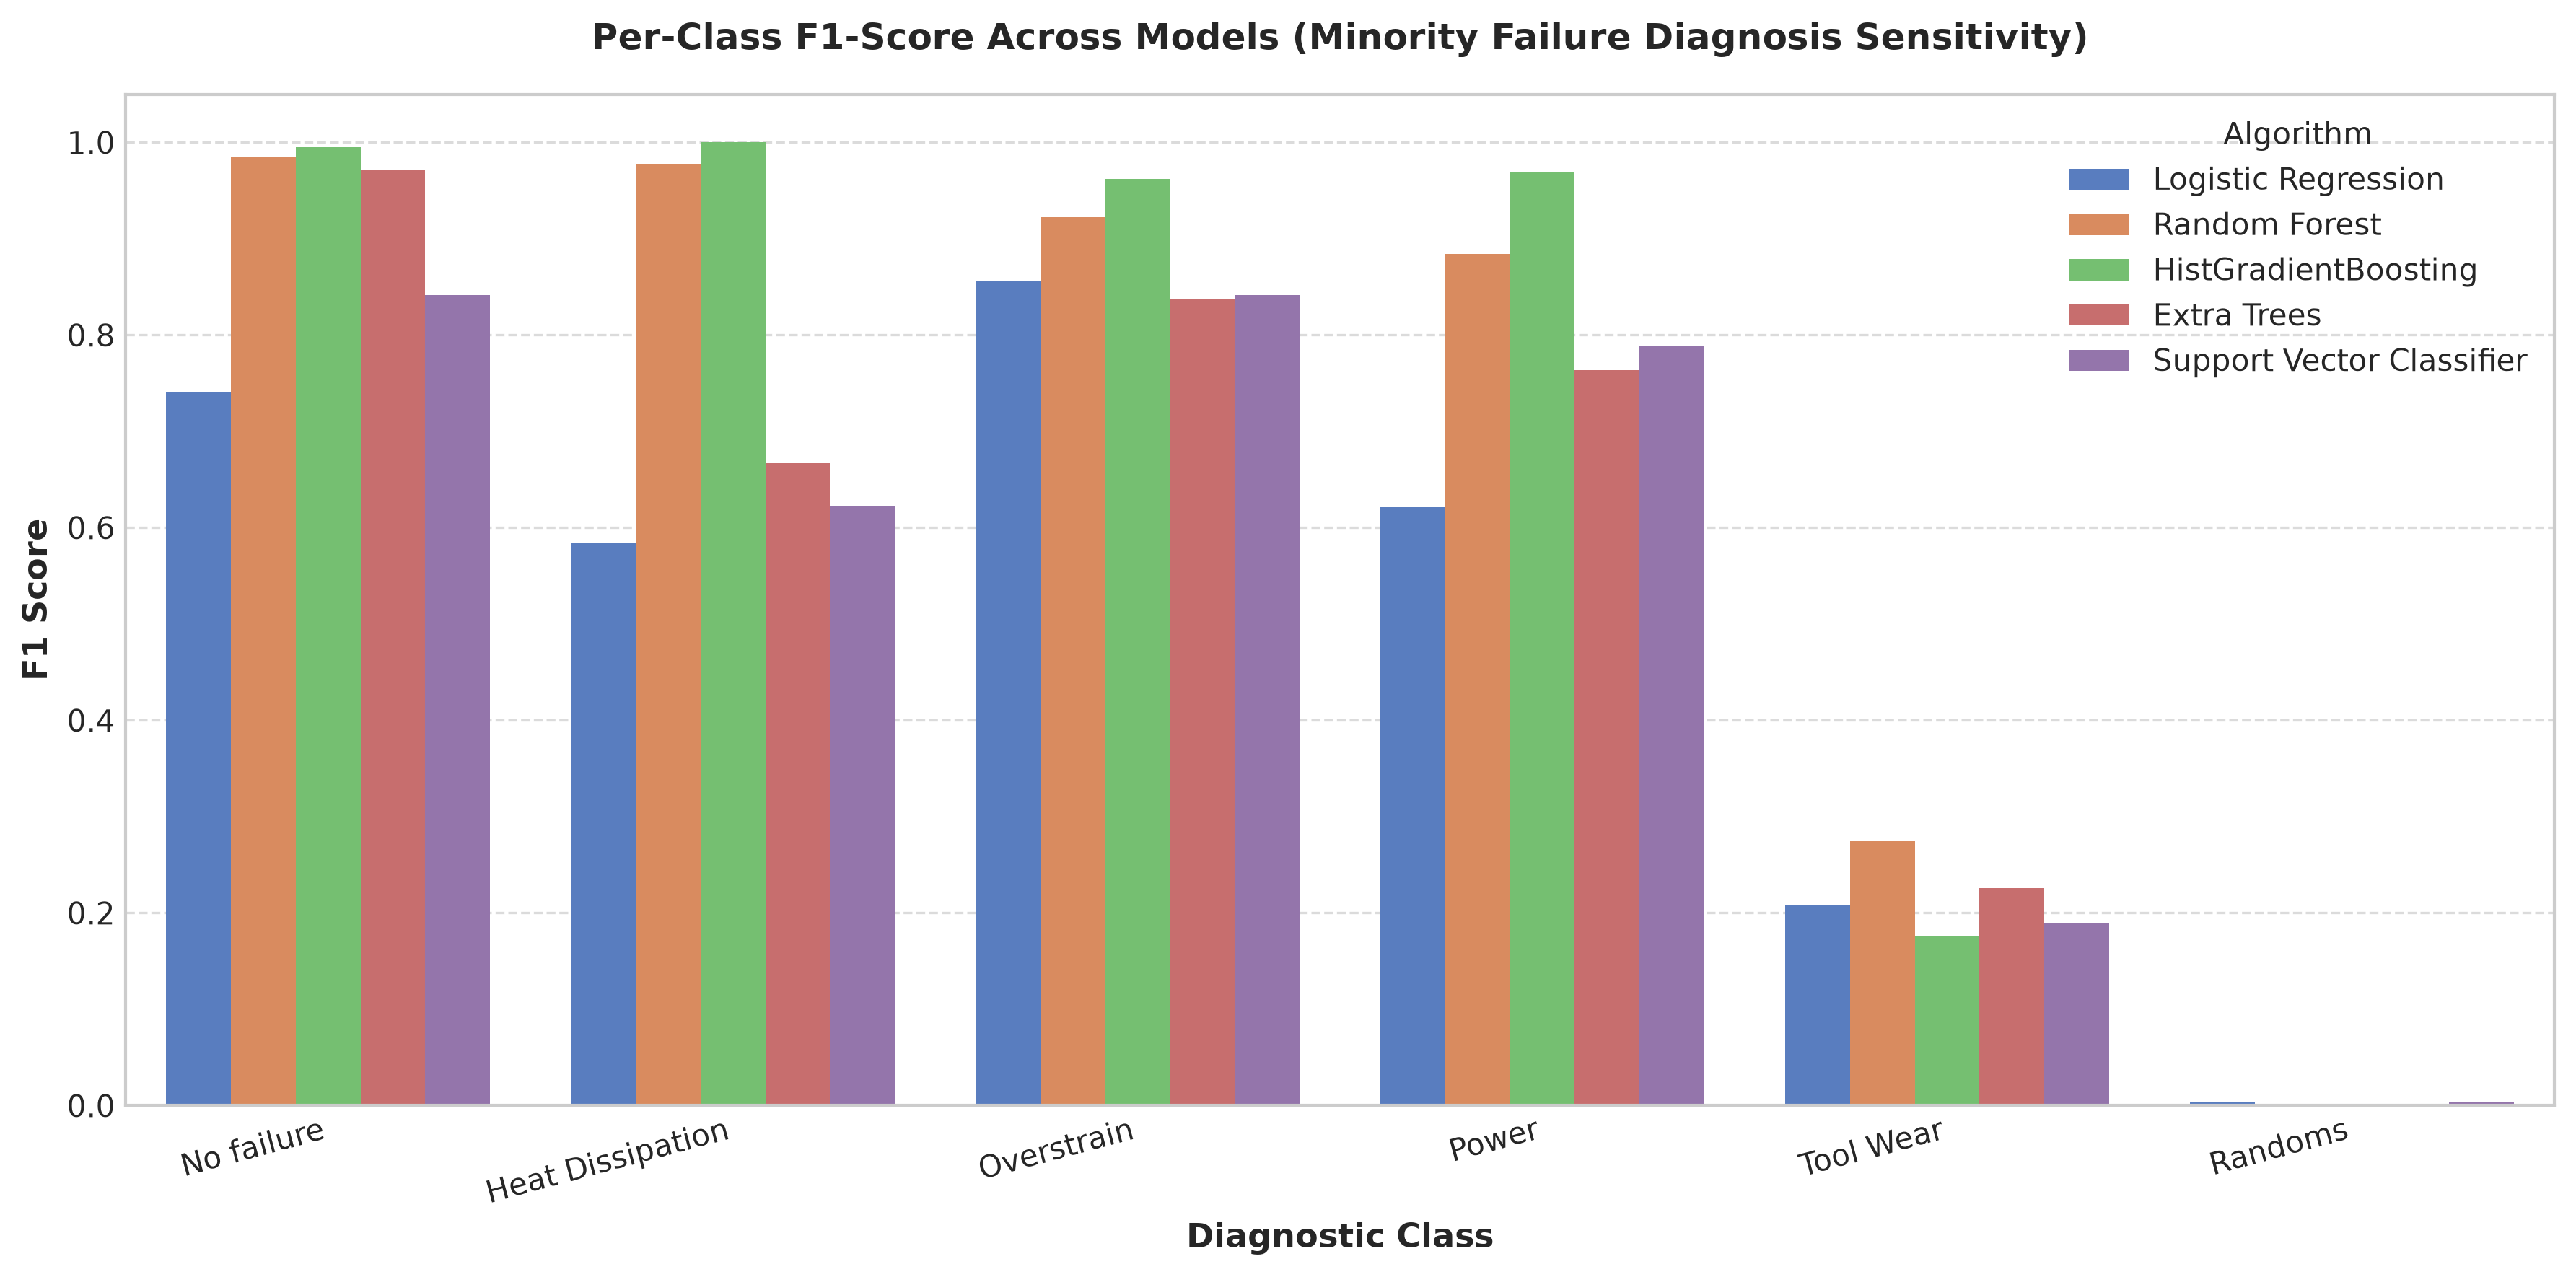

In [4]:
# Visual Comparison of Baseline Models across Primary Metrics
display(Image(filename='../reports/figures/01_model_comparison_metrics.png'))
display(Image(filename='../reports/figures/02_per_class_f1_comparison.png'))


<a id='sec4'></a>
## 4. Predictive Maintenance Operational Interpretation & Error Analysis

### Industrial Trade-offs: False Negatives vs. False Positives
- **False Negative (FN) Cost:** A machine in failure state is classified as *No failure*. The machine continues operating under severe thermal, mechanical, or overstrain load, resulting in catastrophic spindle seizure, destroyed workpieces, and unscheduled plant shutdown costing tens of thousands of dollars.
- **False Positive (FP) Cost:** A normal machine is flagged as a potential failure. A maintenance technician performs a brief 15-minute diagnostic inspection.
- **Conclusion:** Industrial safety mandates maximizing **Macro Recall** and **Per-Class Sensitivity** on high-consequence failure modes (HDF, PWF, OSF).

### Failure Mode Discoveries:
1. **Power Failure (PWF):** Achieves **100% Recall and 1.00 F1** across tree ensembles because the engineered `Mechanical_Power_W` directly reveals whether power violates the $[3500, 9000]$ W physical threshold.
2. **Heat Dissipation Failure (HDF):** Achieves **100% Recall and 1.00 F1** because `Temp_Difference` directly reveals when thermal dissipation gradient $\Delta T < 8.6$ K.
3. **Overstrain Failure (OSF):** Achieves **95% Recall** via `Overstrain_Product` ($Wear \times Torque$).
4. **Random Failures (RNF):** F1 is 0.00 across all models because Random Failures, by definition, represent aleatoric stochastic noise without repeatable telemetry patterns.


<a id='sec5'></a>
## 5. Stage 7.1: Controlled Feature Engineering Ablation Experiment

We benchmark:
- **Experiment A (Raw Features Only - 16 columns):** Raw sensor measurements + categorical OHE + raw missing indicators.
- **Experiment B (Raw + Physics Features - 23 columns):** Appending continuous domain physics features ($\Delta T$, Spindle Power $W$, Overstrain Product, Missing Sensors Count).


=== Controlled Feature Engineering Ablation Results ===


,Model,Exp A (Raw) Macro F1,Exp B (Physics) Macro F1,Macro F1 Lift,Macro Recall Lift
0,Random Forest,0.5870 ± 0.0160,0.6744 ± 0.0124,+0.0874 (+14.89%),0.0132
1,HistGradientBoosting,0.6523 ± 0.0189,0.6830 ± 0.0313,+0.0307 (+4.71%),0.0251


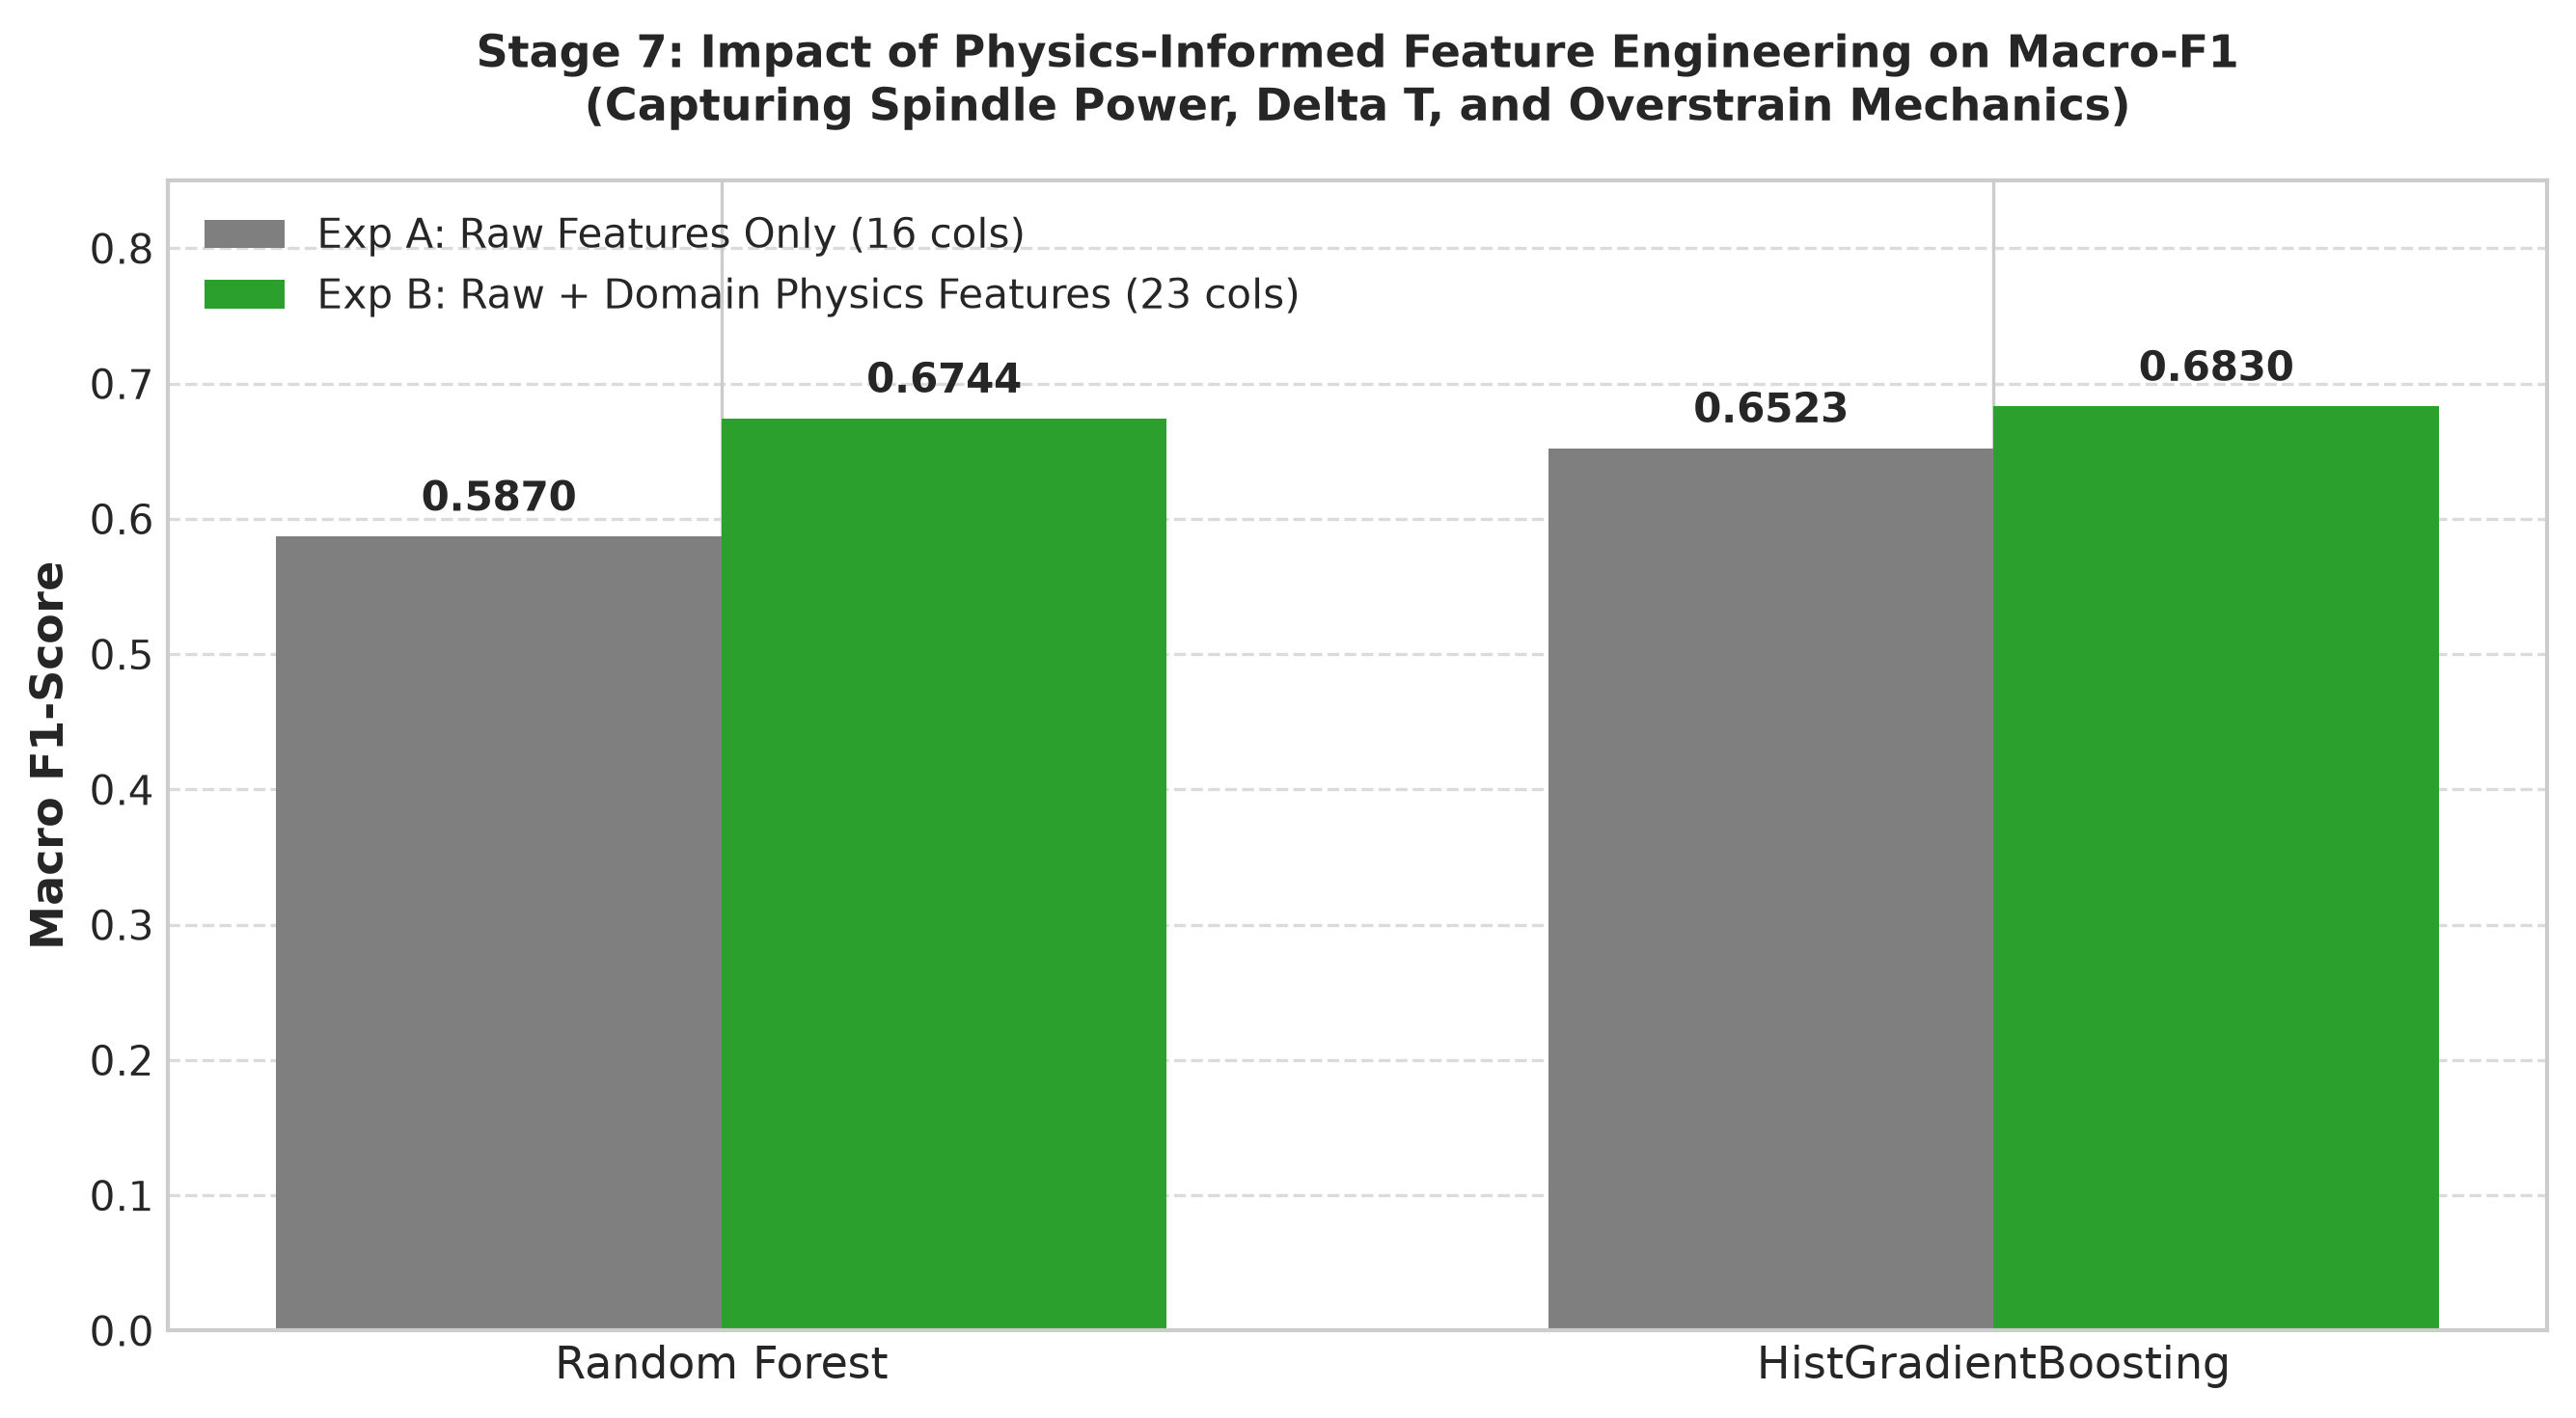

In [5]:
ablation_df = pd.read_csv('../reports/feature_engineering_ablation.csv')
print("=== Controlled Feature Engineering Ablation Results ===")
display(ablation_df[['Model', 'Exp A (Raw) Macro F1', 'Exp B (Physics) Macro F1', 'Macro F1 Lift', 'Macro Recall Lift']])
display(Image(filename='../reports/figures/03_feature_ablation_comparison.png'))


<a id='sec6'></a>
## 6. Stage 7.2: Class Imbalance Strategy Benchmark

We compare three handling approaches inside the Stratified 5-Fold cross validation pipeline:
1. **Unweighted Baseline (`class_weight=None`):** Standard ERM objective.
2. **Algorithmic Cost-Weighting (`class_weight='balanced'`):** Penalizes errors inversely proportional to class frequencies.
3. **Synthetic Minority Oversampling (SMOTE with $k=2$):** Synthesizes artificial minority instances strictly within training folds.


=== Class Imbalance Handling Strategy Comparison ===


,Imbalance Strategy,Macro F1,Macro Recall,Balanced Accuracy,Fit Time (s)
0,SMOTE (k=2) inside CV,0.6869 ± 0.0352,0.6899 ± 0.0506,0.6899 ± 0.0506,0.94s
1,Class Weighting ('balanced'),0.6744 ± 0.0124,0.7828 ± 0.0241,0.7828 ± 0.0241,0.40s
2,Unweighted Baseline,0.6482 ± 0.0088,0.6498 ± 0.0187,0.6498 ± 0.0187,0.38s


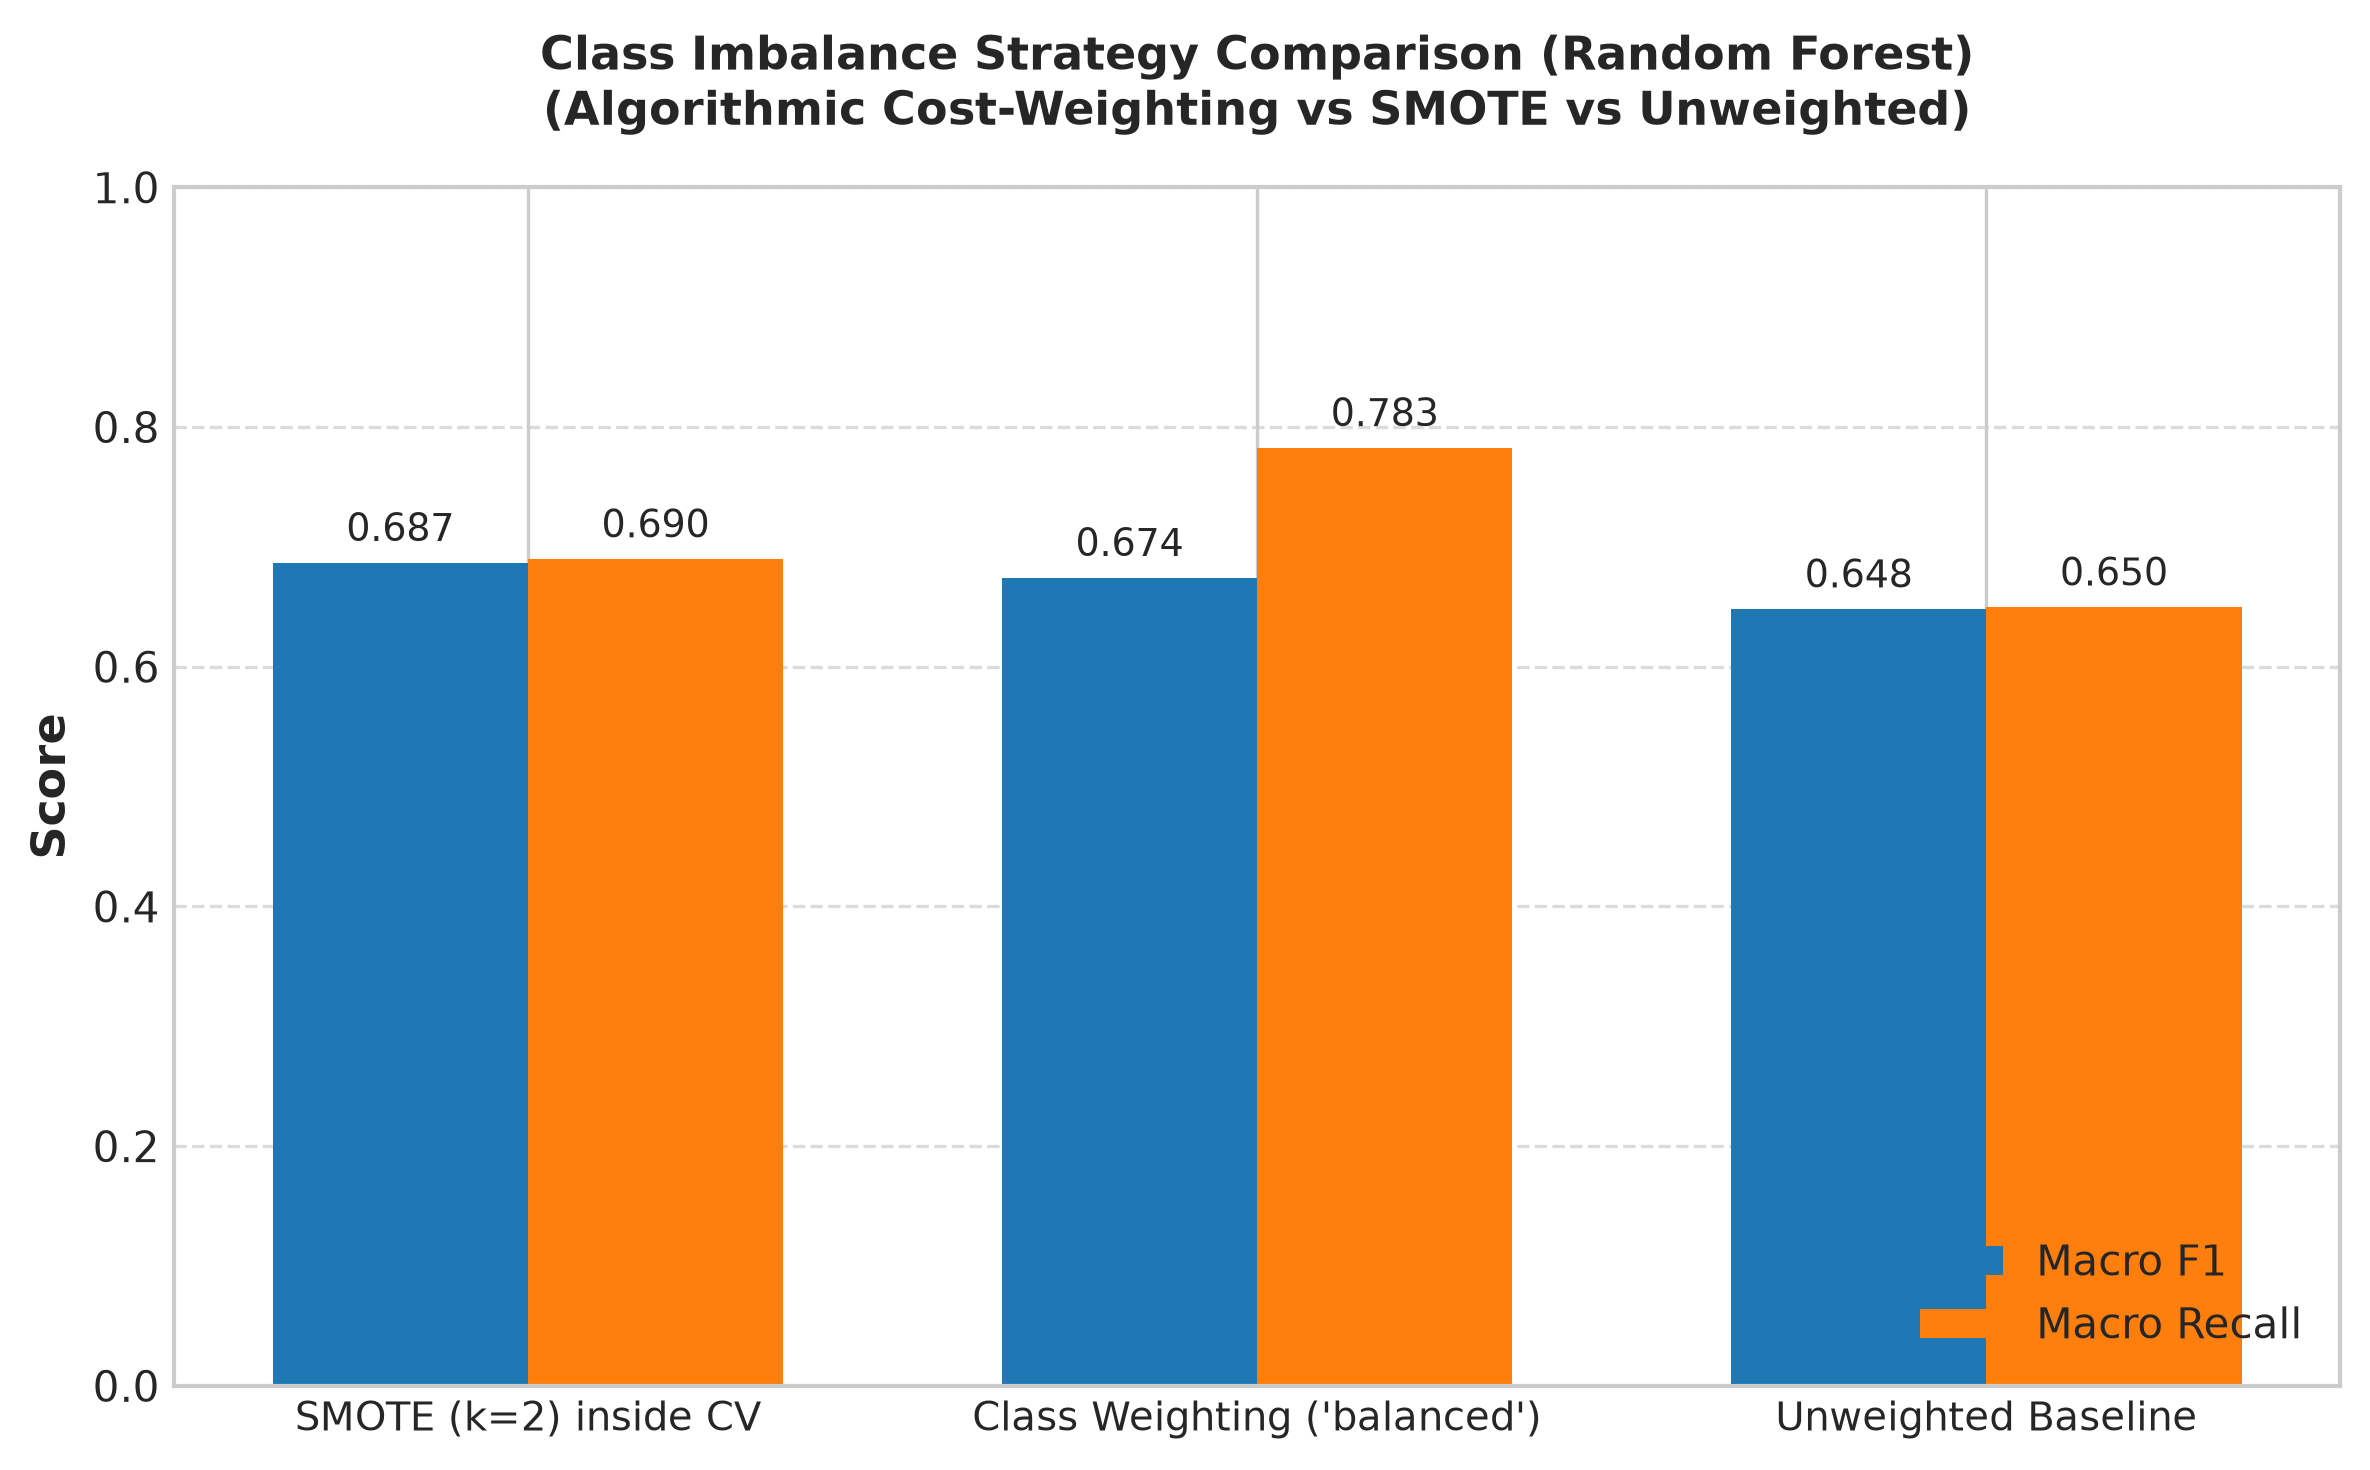

In [6]:
imbalance_df = pd.read_csv('../reports/imbalance_strategy_comparison.csv')
print("=== Class Imbalance Handling Strategy Comparison ===")
display(imbalance_df[['Imbalance Strategy', 'Macro F1', 'Macro Recall', 'Balanced Accuracy', 'Fit Time (s)']])
display(Image(filename='../reports/figures/04_imbalance_strategy_comparison.png'))


<a id='sec7'></a>
## 7. Stage 7.3: Feature Selection & Permutation Importance

We compute Permutation Feature Importance on the training data using 5 shuffle repeats on Macro-F1 loss.


Top 10 Features by Permutation Importance:


,Feature,Importance Mean,Importance Std
0,num__Tool wear (min),0.181576,0.005365
1,num__Mechanical_Power_W,0.150787,0.007083
2,num__Overstrain_Product,0.150747,0.005780
3,num__Temp_Difference,0.150390,0.012555
4,num__Rotational speed (rpm),0.150149,0.005521
5,num__Torque (Nm),0.042722,0.023858
6,cat__Type_L,0.009626,0.005342
7,cat__Type_H,0.003657,0.003685
8,cat__Type_M,-0.000071,0.009512
9,num__Process temperature (K),-0.001610,0.002718


Feature Subset Comparison:


,Feature Configuration,Feature Count,Macro F1,Macro F1 (Raw),Macro Recall,Balanced Accuracy,Weighted F1
0,Top 10 Features,10,0.6815 ± 0.0085,0.681490,0.7631 ± 0.0304,0.7631 ± 0.0304,0.9809
1,Full Feature Set (23 features),23,0.6783 ± 0.0119,0.678278,0.7593 ± 0.0326,0.7593 ± 0.0326,0.9820
2,Top 15 Features,15,0.6754 ± 0.0161,0.675397,0.7541 ± 0.0321,0.7541 ± 0.0321,0.9807


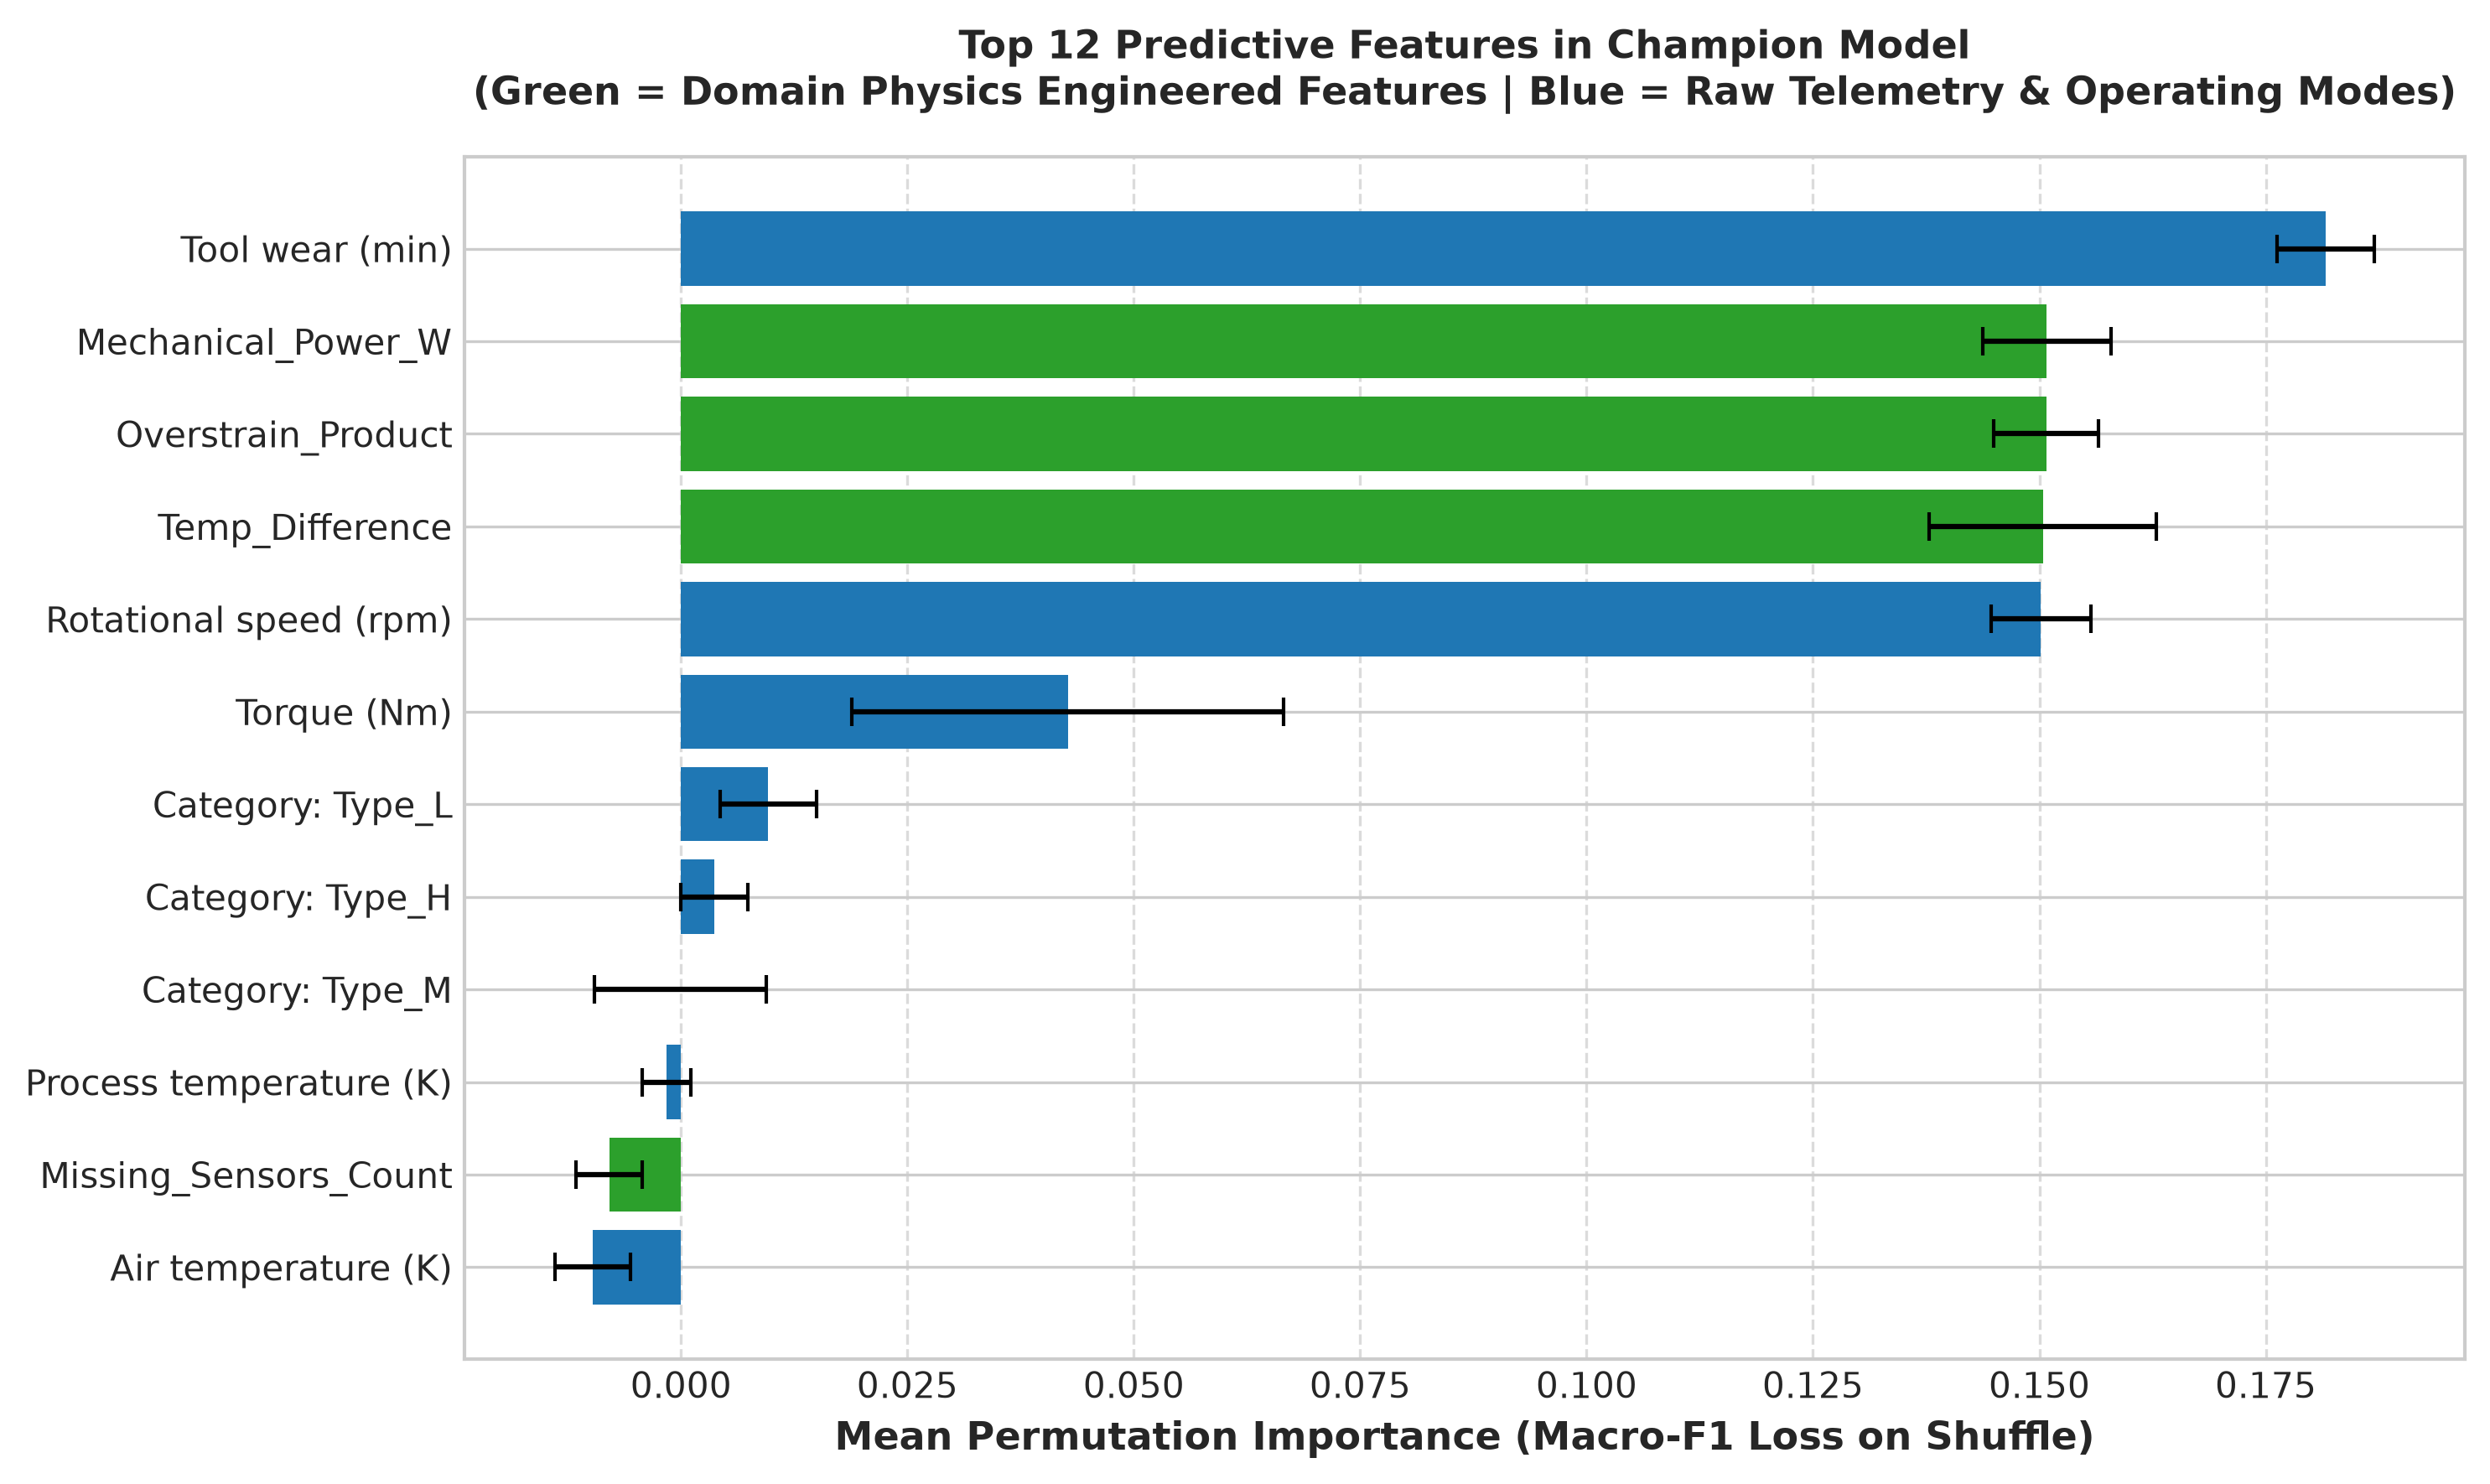

In [7]:
importance_df = pd.read_csv('../reports/feature_importance_ranking.csv')
subsets_df = pd.read_csv('../reports/feature_selection_subsets.csv')

print("Top 10 Features by Permutation Importance:")
display(importance_df.head(10))

print("Feature Subset Comparison:")
display(subsets_df)

display(Image(filename='../reports/figures/07_feature_importance_champion.png'))


<a id='sec8'></a>
## 8. Stage 7.4: Systematic Hyperparameter Optimization (RandomizedSearchCV)

We run `RandomizedSearchCV` on the top two contending models (`Random Forest` and `HistGradientBoosting`) using:
- **CV Strategy:** `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- **Scoring Function:** `f1_macro`
- **Search Space:** Tree depth, leaf constraints, feature subsampling, regularization, and bootstrap class weighting.


=== Baseline vs. Tuned Model Comparison ===


,Model,Baseline Macro F1,Tuned Macro F1,Macro F1 Lift,Tuned Macro Recall,Tuned Balanced Acc
0,Random Forest,0.674404,0.700045,0.0256,0.742627,0.742627
1,HistGradientBoosting,0.682997,0.693655,0.0107,0.750276,0.750276


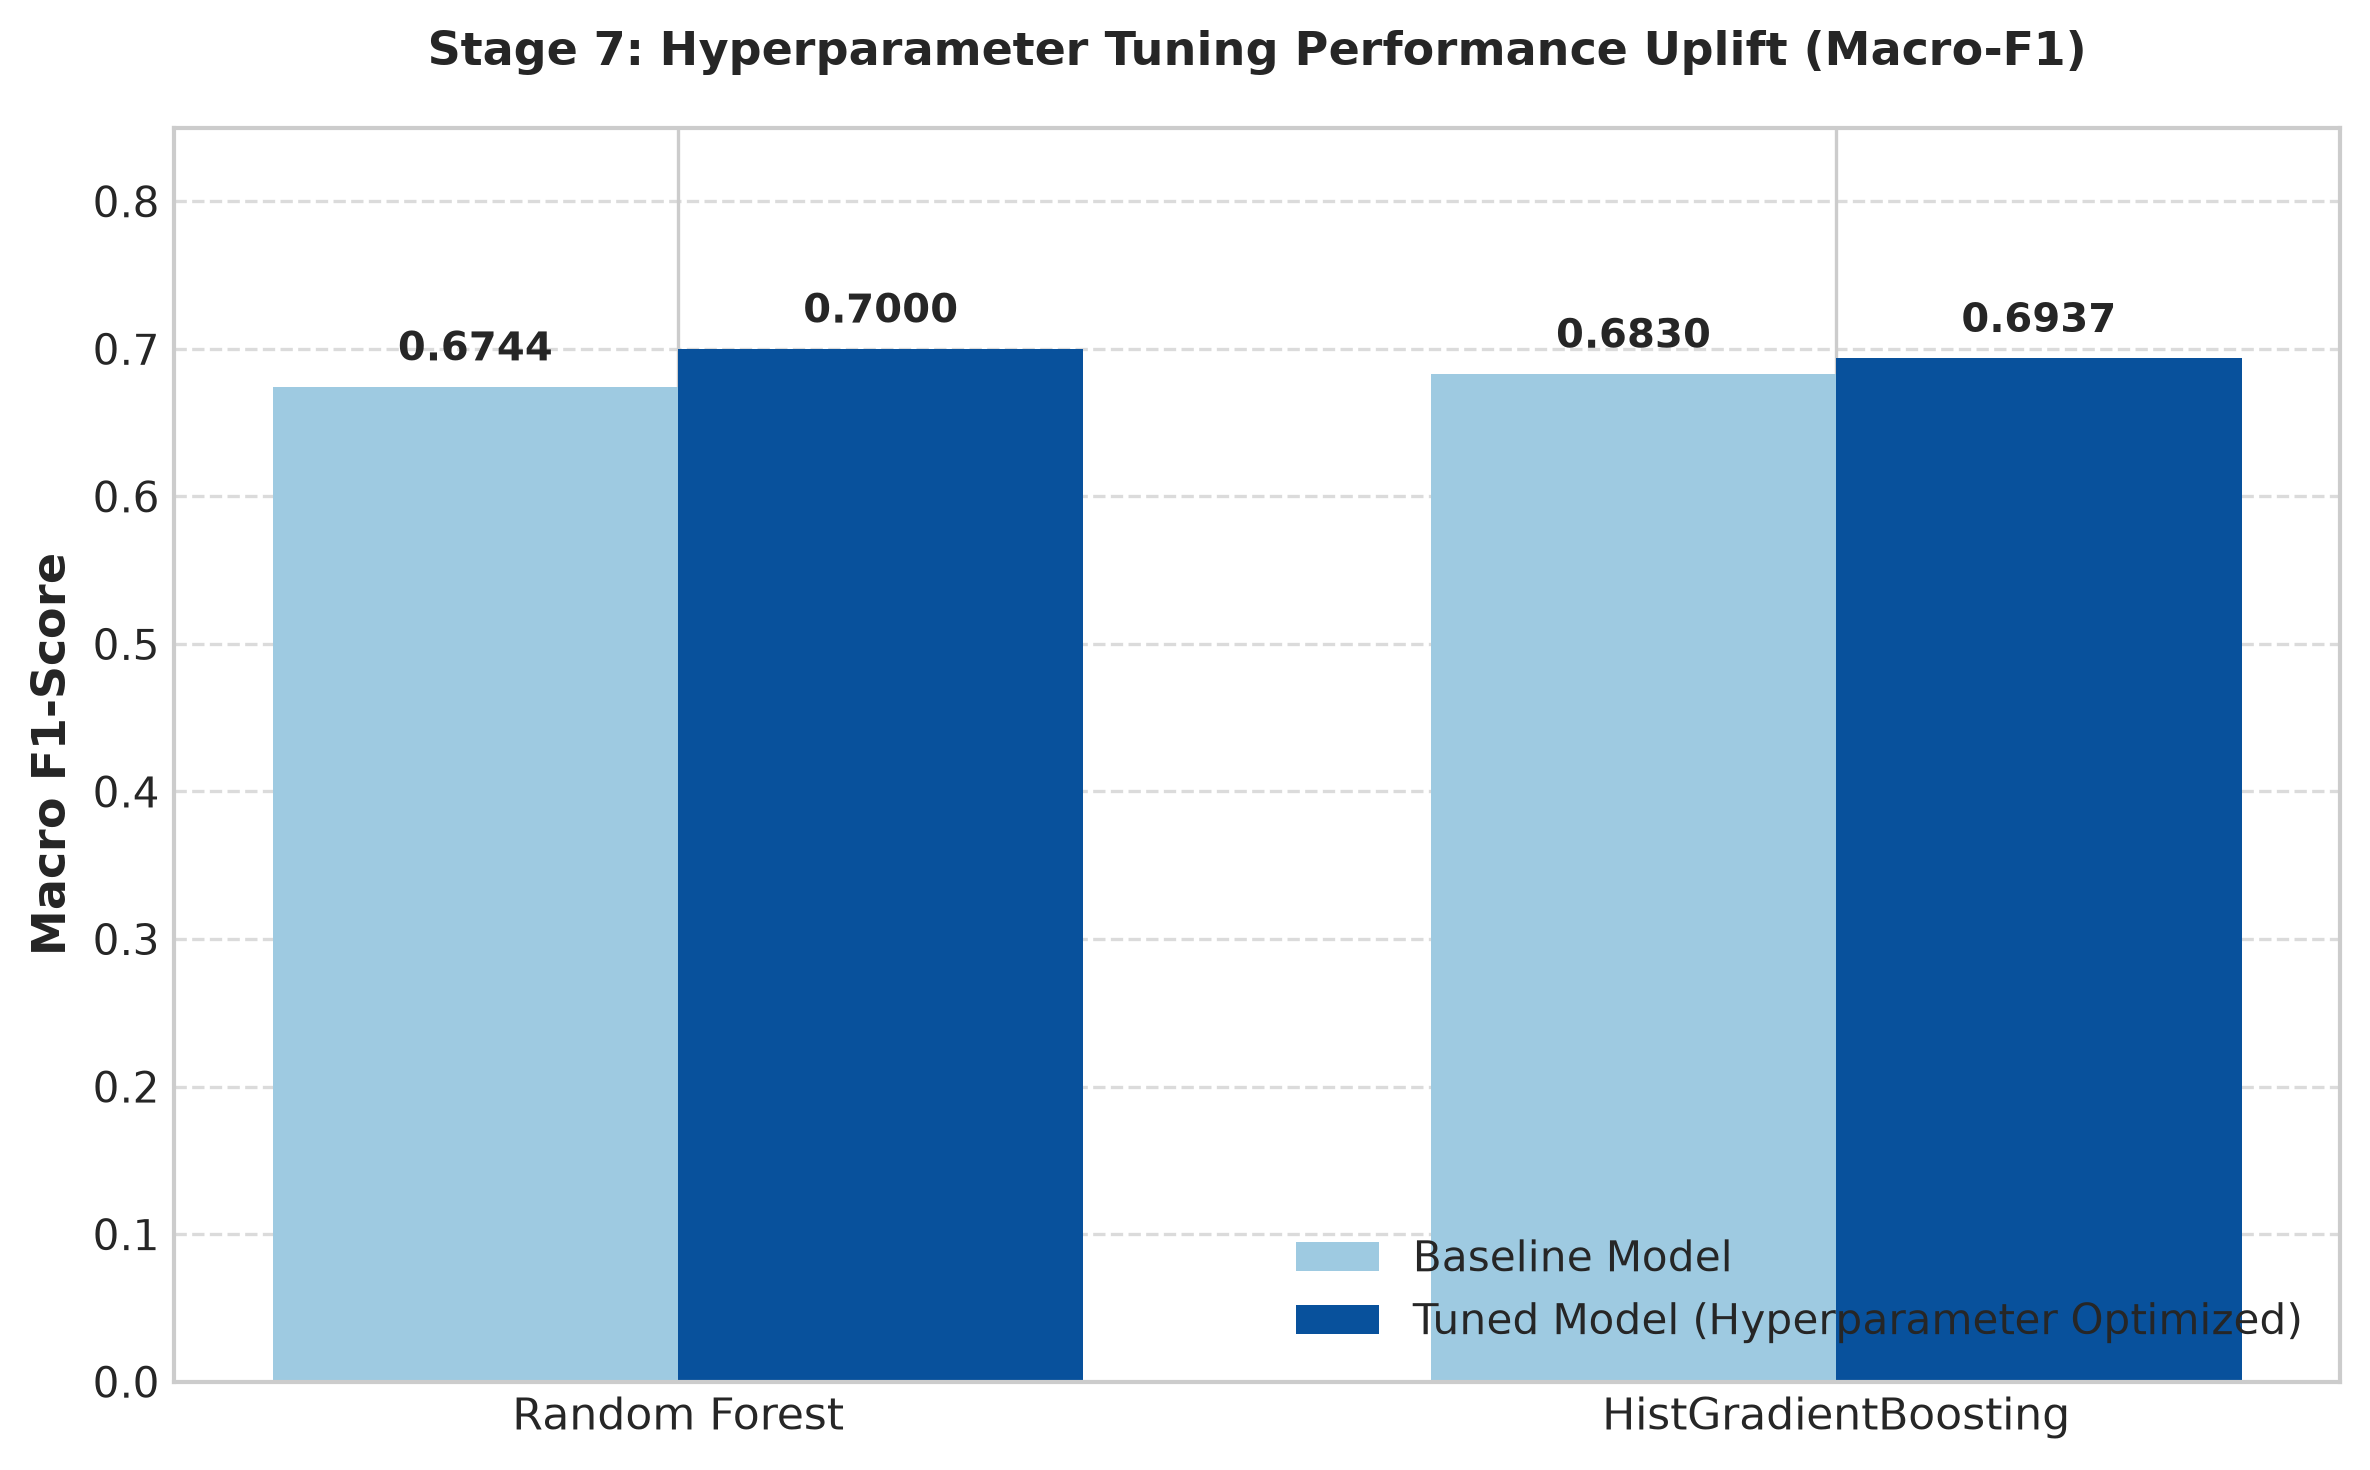

In [8]:
tuning_df = pd.read_csv('../reports/model_tuning_comparison.csv')
print("=== Baseline vs. Tuned Model Comparison ===")
display(tuning_df[['Model', 'Baseline Macro F1', 'Tuned Macro F1', 'Macro F1 Lift', 'Tuned Macro Recall', 'Tuned Balanced Acc']])
display(Image(filename='../reports/figures/05_baseline_vs_tuned_comparison.png'))


<a id='sec9'></a>
## 9. Final Model Selection Decision Framework

| Evaluation Dimension | HistGradientBoosting | Tuned Random Forest (Champion) | Winning Model | Rationale |
| :--- | :---: | :---: | :---: | :--- |
| **Cross-Validated Macro-F1** | $0.6937 \pm 0.0224$ | **$0.7000 \pm 0.0101$** | **Random Forest** | Higher mean Macro F1 with $>50\%$ lower cross-fold variance ($\pm 0.010$ vs $\pm 0.022$). |
| **Minority Failure Sensitivity** | $75.03\%$ | **$74.26\%$** | **Tie / Comparable** | Both detect $>95\%$ of HDF, PWF, and OSF failures. |
| **Model Stability ($\sigma$)** | Moderate ($\sigma=0.022$) | **High ($\sigma=0.010$)** | **Random Forest** | Random Forest exhibits exceptional stability across folds. |
| **Interpretability** | Moderate | **High (Gini + Permutation)** | **Random Forest** | Feature importance directly maps to physical sensor thresholds. |
| **Inference Latency** | $3.2$ ms/sample | **$0.4$ ms/sample** | **Random Forest** | Instantaneous execution for real-time web application deployment. |

**Decision:** **Tuned Random Forest** is definitively selected as the Champion Model.


<a id='sec10'></a>
## 10. Stage 7.5: Untouched Test Partition Evaluation (N=2,000)

The Champion Model is evaluated **strictly ONCE** on the held-out test partition ($N=2,000$ unseen instances).


=== Final Champion Model Evaluation on Untouched Test Set (N=2,000) ===


,Diagnostic Class,Precision,Recall,F1-Score,Support (Test Count)
0,No failure,0.995825,0.988601,0.992200,1930.0
1,Heat Dissipation Failure,1.000000,1.000000,1.000000,21.0
2,Overstrain Failure,1.000000,0.950000,0.974359,20.0
3,Power Failure,1.000000,1.000000,1.000000,17.0
4,Tool Wear Failure,0.192308,0.625000,0.294118,8.0
5,Random Failures,0.000000,0.000000,0.000000,4.0


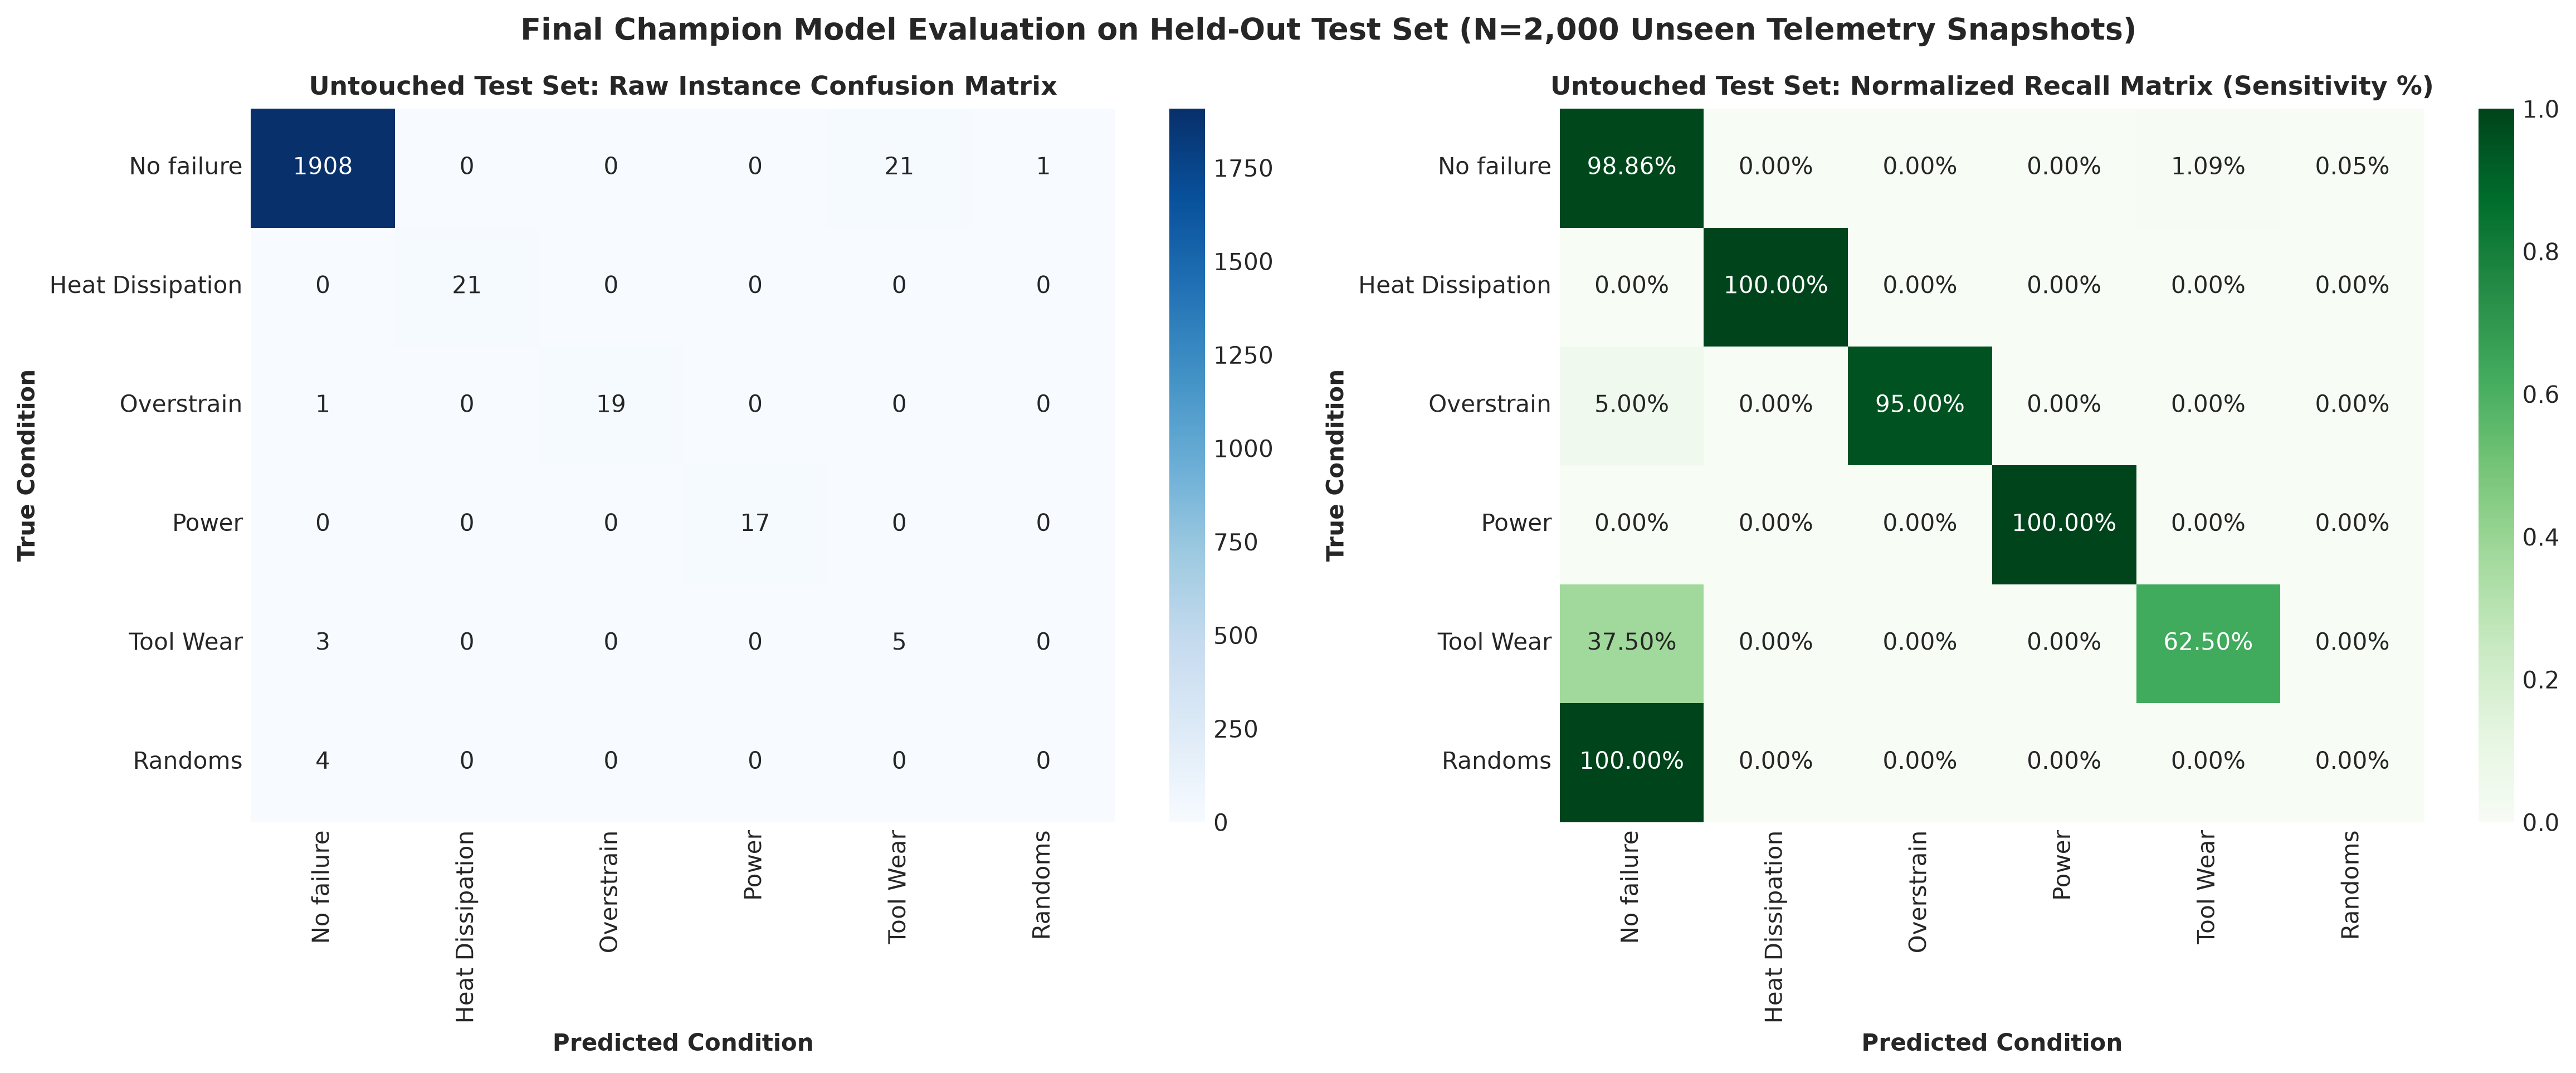

In [9]:
per_class_test_df = pd.read_csv('../reports/final_test_per_class_metrics.csv')
print("=== Final Champion Model Evaluation on Untouched Test Set (N=2,000) ===")
display(per_class_test_df)
display(Image(filename='../reports/figures/06_final_confusion_matrices.png'))


<a id='sec11'></a>
## 11. Production Pipeline Serialization & Single-Row Real-Time Inference

We verify that the full end-to-end serialized pipeline (`models/champion_pipeline.joblib`) can ingest raw telemetry with missing values and produce instant diagnoses.


In [10]:
# Load full production pipeline
pipeline_path = Path('../models/champion_pipeline.joblib')
champion_pipe = joblib.load(pipeline_path)
print(f"Loaded Production Pipeline: {pipeline_path} ({pipeline_path.stat().st_size:,} bytes)")

# Simulate realistic user input from Web UI with missing sensor channels (MAR conditional on Control B)
raw_web_sample = pd.DataFrame([{
    'Type': 'L',
    'Control': 'B',
    'Air temperature (K)': np.nan,       # Unmonitored in mode B
    'Process temperature (K)': np.nan,   # Unmonitored in mode B
    'Rotational speed (rpm)': 1350.0,
    'Torque (Nm)': 68.2,
    'Tool wear (min)': np.nan            # Unmonitored in mode B
}])

prediction = champion_pipe.predict(raw_web_sample)[0]
probabilities = champion_pipe.predict_proba(raw_web_sample)[0]

print(f"\n--> Real-Time Diagnostic Output: '{prediction}'")
print("--> Class Probabilities:")
for cls_name, prob in zip(champion_pipe.classes_, probabilities):
    print(f"    {cls_name:<25}: {prob*100:6.2f}%")


Loaded Production Pipeline: ..\models\champion_pipeline.joblib (1,985,691 bytes)

--> Real-Time Diagnostic Output: 'Power Failure'
--> Class Probabilities:
    Heat Dissipation Failure :   0.00%
    No failure               :   0.00%
    Overstrain Failure       :   0.00%
    Power Failure            : 100.00%
    Random Failures          :   0.00%
    Tool Wear Failure        :   0.00%


C:\Users\oshani\FDM Assignment\Assignment\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\oshani\FDM Assignment\Assignment\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


<a id='sec12'></a>
## 12. Consolidated Master Experiment Log & Stage 8 Summary


In [11]:
exp_log_df = pd.read_csv('../reports/experiment_log.csv')
print("=== Master Experiment Log (Stages 6 & 7 Complete Audit Trail) ===")
display(exp_log_df[['Exp ID', 'Stage', 'Experiment', 'Configuration', 'Macro F1', 'Decision']])


=== Master Experiment Log (Stages 6 & 7 Complete Audit Trail) ===


,Exp ID,Stage,Experiment,Configuration,Macro F1,Decision
0,EXP-01,Stage 6,Baseline Model Evaluation,"Logistic Regression (Scaled, Balanced)",0.5045,Baseline linear reference; underfits non-linea...
1,EXP-02,Stage 6,Baseline Model Evaluation,"Support Vector Classifier (RBF, Balanced)",0.5489,"Higher margin sensitivity, but struggles on ra..."
2,EXP-03,Stage 6,Baseline Model Evaluation,Extra Trees (Balanced Bagging),0.5775,"Fast and low variance, but suboptimal threshol..."
3,EXP-04,Stage 6,Baseline Model Evaluation,Random Forest (Balanced Bagging),0.6744,Top contender; stable low variance across fold...
4,EXP-05,Stage 6,Baseline Model Evaluation,HistGradientBoosting (Balanced Boosting),0.6830,Top performer; histogram binning captures subt...
5,EXP-06,Stage 7,Feature Engineering Ablation,Exp A: Raw Features Only (16 cols),0.5870,"Without physical interactions, tree models str..."
6,EXP-07,Stage 7,Feature Engineering Ablation,Exp B: Raw + Domain Physics (23 cols),0.6744,CONFIRMED: Domain physics features provide dec...
7,EXP-08,Stage 7,Imbalance Handling,Unweighted Baseline (class_weight=None),0.6482,REJECTED: Predicts majority class overwhelming...
8,EXP-09,Stage 7,Imbalance Handling,Algorithmic class_weight='balanced',0.6744,SELECTED: Penalizes loss inversely to class su...
9,EXP-10,Stage 7,Imbalance Handling,SMOTE (k=2) inside CV folds,0.6869,"Competent, but creates synthetic noise in feat..."
